# Data Preprocessing

In [ ]:
# import necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import mne
import trimesh
import plotly.graph_objects as go
from mpl_toolkits.mplot3d import Axes3D
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt

In [ ]:
# load the dataset
df = pd.read_csv('AD_all_patients.csv')
df.head()

,Fp1,Fp2,F7,F3,Fz,F4,F8,T3,C3,Cz,C4,T4,T5,P3,Pz,P4,status
0,116.99375,41.09375,66.69375,-64.50625,-126.40625,8.39375,22.49375,42.19375,53.29375,4.49375,2.49375,73.79375,129.29375,0.09375,-124.90625,-245.50625,1
1,115.93125,38.63125,64.73125,-64.66875,-125.26875,8.73125,27.03125,43.23125,57.53125,11.13125,2.33125,72.23125,125.73125,-5.46875,-123.06875,-248.76875,1
2,115.72500,38.32500,66.02500,-62.67500,-135.37500,9.02500,29.42500,47.12500,49.92500,24.42500,1.22500,72.92500,123.22500,-3.07500,-129.97500,-246.27500,1
3,120.15625,40.75625,71.05625,-59.54375,-148.34375,12.15625,32.25625,49.05625,41.05625,12.75625,1.85625,73.55625,128.65625,-0.14375,-133.24375,-242.04375,1
4,119.50000,39.50000,71.30000,-59.20000,-125.50000,14.80000,28.50000,48.80000,42.20000,-1.20000,1.40000,70.30000,116.10000,3.40000,-129.00000,-240.90000,1


In [4]:
df.shape

(848640, 17)

In [5]:
df.describe()



,Fp1,Fp2,F7,F3,Fz,F4,F8,T3,C3,Cz,C4,T4,T5,P3,Pz,P4,status
count,848640.000000,848640.000000,848640.000000,848640.000000,848640.000000,848640.000000,848640.000000,848640.000000,848640.00000,848640.000000,848640.000000,848640.000000,848640.000000,848640.000000,848640.000000,848640.000000,848640.000000
mean,9.197634,23.204037,-11.428283,4.300583,-26.751948,-19.904077,-11.155309,-21.950993,18.05179,18.132288,16.903650,17.301845,-13.820743,-4.300905,39.719552,-37.499122,0.603318
std,107.877150,74.794207,60.968966,50.977283,77.433634,52.194458,147.858085,75.109347,36.53587,84.863804,65.831297,43.450596,63.844198,41.639673,59.709989,82.382886,0.489209
min,-698.175000,-555.575000,-334.400000,-460.775000,-434.975000,-572.075000,-1000.331250,-1006.575000,-465.37500,-163.743750,-451.425000,-451.675000,-726.368750,-487.075000,-385.775000,-646.412500,0.000000
25%,-25.956250,-10.381250,-38.181250,-19.387500,-42.243750,-39.475000,-22.768750,-55.868750,-2.60625,-11.087500,-9.300000,-4.918750,-29.018750,-21.412500,4.906250,-36.906250,0.000000
50%,-11.800000,2.256250,-7.100000,-1.056250,-13.931250,-18.025000,2.762500,-8.693750,12.91875,1.765625,7.187500,6.781250,-3.400000,-6.225000,24.062500,-12.568750,1.000000
75%,23.268750,35.487500,20.868750,19.387500,5.645313,7.362500,29.075000,13.743750,29.70000,24.175000,39.981250,23.875000,11.912500,11.425000,72.312500,4.425000,1.000000
max,7077.325000,376.937500,409.137500,638.925000,533.962500,227.187500,1152.418750,281.562500,346.96875,805.356250,343.512500,358.931250,244.687500,214.700000,595.250000,115.893750,1.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 848640 entries, 0 to 848639
Data columns (total 17 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Fp1     848640 non-null  float64
 1   Fp2     848640 non-null  float64
 2   F7      848640 non-null  float64
 3   F3      848640 non-null  float64
 4   Fz      848640 non-null  float64
 5   F4      848640 non-null  float64
 6   F8      848640 non-null  float64
 7   T3      848640 non-null  float64
 8   C3      848640 non-null  float64
 9   Cz      848640 non-null  float64
 10  C4      848640 non-null  float64
 11  T4      848640 non-null  float64
 12  T5      848640 non-null  float64
 13  P3      848640 non-null  float64
 14  Pz      848640 non-null  float64
 15  P4      848640 non-null  float64
 16  status  848640 non-null  int64  
dtypes: float64(16), int64(1)
memory usage: 110.1 MB


In [7]:
df.isna().sum()

Fp1       0
Fp2       0
F7        0
F3        0
Fz        0
F4        0
F8        0
T3        0
C3        0
Cz        0
C4        0
T4        0
T5        0
P3        0
Pz        0
P4        0
status    0
dtype: int64

In [8]:
df.isnull().sum()

Fp1       0
Fp2       0
F7        0
F3        0
Fz        0
F4        0
F8        0
T3        0
C3        0
Cz        0
C4        0
T4        0
T5        0
P3        0
Pz        0
P4        0
status    0
dtype: int64

### Dataset is in healthy condition, there are neither null values nor missing values

#### Dataset Observation
This dataset contains 848,640 records with 17 columns, representing EEG (Electroencephalogram) signals recorded from multiple electrode positions on the scalp, along with a status label. The dataset is be related to the study of Alzheimer’s Disease (AD).

Features (16 continuous variables, float64):
Each feature corresponds to the electrical activity recorded from standard EEG electrode placements based on the international 10-20 system:

Fp1, Fp2, F7, F3, Fz, F4, F8
T3, C3, Cz, C4, T4
T5, P3, Pz, P4

These channels measure brain activity in different cortical regions (frontal, temporal, central, and parietal lobes).
Target variable (1 categorical variable, int64)
- status: 0: Healthy, 1: Alzheimers.
- Size & Integrity:
- Rows: 848,640 samples
- Columns: 17 (16 EEG features + 1 status label)
- Data types: 16 float features, 1 integer label
- Missing values: None (clean dataset)

In [5]:
df.columns

Index(['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'T3', 'C3', 'Cz', 'C4',
       'T4', 'T5', 'P3', 'Pz', 'P4', 'status'],
      dtype='object')

In [40]:
df.shape

(848640, 17)

In [39]:
df.duplicated().sum()

np.int64(1036)

In [41]:
df = df.drop_duplicates()
df.shape

(847604, 17)

In [ ]:
montage = mne.channels.make_standard_montage("standard_1020")
print(montage.ch_names)  # full list
xyz = montage.get_positions()['ch_pos']  # dict: electrode -> (x, y, z)
print(xyz)  # positions

['Fp1', 'Fpz', 'Fp2', 'AF9', 'AF7', 'AF5', 'AF3', 'AF1', 'AFz', 'AF2', 'AF4', 'AF6', 'AF8', 'AF10', 'F9', 'F7', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'F8', 'F10', 'FT9', 'FT7', 'FC5', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'FC6', 'FT8', 'FT10', 'T9', 'T7', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'T8', 'T10', 'TP9', 'TP7', 'CP5', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'CP6', 'TP8', 'TP10', 'P9', 'P7', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'P8', 'P10', 'PO9', 'PO7', 'PO5', 'PO3', 'PO1', 'POz', 'PO2', 'PO4', 'PO6', 'PO8', 'PO10', 'O1', 'Oz', 'O2', 'O9', 'Iz', 'O10', 'T3', 'T5', 'T4', 'T6', 'M1', 'M2', 'A1', 'A2']
OrderedDict({'Fp1': array([-0.0294367,  0.0839171, -0.00699  ]), 'Fpz': array([ 0.0001123,  0.088247 , -0.001713 ]), 'Fp2': array([ 0.0298723,  0.0848959, -0.00708  ]), 'AF9': array([-0.0489708,  0.0640872, -0.047683 ]), 'AF7': array([-0.0548397,  0.0685722, -0.01059  ]), 'AF5': array([-0.0454307,  0.0728622,  0.005978 ]), 'AF3': array([-0.0337007,  0.0768371,  0.021227 ]), 'AF

In [ ]:
# 1. Load and auto-scale skull
mesh = trimesh.load("craneo.obj")

# Target head width (mm)
target_width = 180  
bbox = mesh.bounds
current_width = bbox[1][0] - bbox[0][0]
scale_factor = target_width / current_width
mesh.apply_scale(scale_factor)

# 2. Electrode coordinates from montage (already normalized)
electrodes_dict = {
    "Fp1": [-0.0294367,  0.0839171, -0.00699],
    "Fp2": [ 0.0298723,  0.0848959, -0.00708],
    "F7" : [-0.0702629,  0.0424743, -0.01142],
    "F3" : [-0.0502438,  0.0531112,  0.042192],
    "Fz" : [0.0003122,   0.058512,   0.066462],
    "F4" : [ 0.0518362,  0.0543048,  0.040814],
    "F8" : [ 0.0730431,  0.0444217, -0.012],
    "T3" : [-0.0841611, -0.0160187, -0.009346],
    "C3" : [-0.0653581, -0.0116317,  0.064358],
    "Cz" : [ 0.0004009, -0.009167,   0.100244],
    "C4" : [ 0.0671179, -0.0109003,  0.06358],
    "T4" : [ 0.0850799, -0.0150203, -0.00949],
    "T5" : [-0.0724343, -0.0734527, -0.002487],
    "P3" : [-0.0530073, -0.0787878,  0.05594],
    "Pz" : [ 0.0003247, -0.081115,   0.082615],
    "P4" : [ 0.0556667, -0.0785602,  0.056561],
    "O1" : [-0.0294134, -0.112449,   0.008839],
    "O2" : [ 0.0298426, -0.112156,   0.0088],
}

# 3. Scale to skull size (~90 mm radius)
scale_coords = 90 / 0.1   # montage radius ~0.1 m
xyz = np.array(list(electrodes_dict.values())) * scale_coords
labels = list(electrodes_dict.keys())

# Project onto skull surface
closest_points, _, _ = trimesh.proximity.closest_point(mesh, xyz)

# 4. Color coding groups
group_colors = {
    "Frontal": "red",
    "Central": "blue",
    "Temporal": "orange",
    "Parietal": "green",
    "Occipital": "purple"
}

# Assign group membership
def get_group(name):
    if name.startswith("F"): return "Frontal"
    if name.startswith("C"): return "Central"
    if name.startswith("T"): return "Temporal"
    if name.startswith("P"): return "Parietal"
    if name.startswith("O"): return "Occipital"
    return "Other"

all_colors = [group_colors[get_group(ch)] for ch in labels]

# 5. Plot in Plotly
vertices = np.array(mesh.vertices)
faces = np.array(mesh.faces)

fig = go.Figure()

# Skull mesh
fig.add_trace(go.Mesh3d(
    x=vertices[:,0], y=vertices[:,1], z=vertices[:,2],
    i=faces[:,0], j=faces[:,1], k=faces[:,2],
    color="darkgrey", opacity=0.5,
    name="Skull"
))

# Electrodes
fig.add_trace(go.Scatter3d(
    x=closest_points[:,0], y=closest_points[:,1], z=closest_points[:,2],
    mode="markers+text",
    marker=dict(size=6, color=all_colors),
    text=labels,
    textposition="top center",
    name="Electrodes"
))

# Legend (dummy traces for groups)
for g, col in group_colors.items():
    fig.add_trace(go.Scatter3d(
        x=[None], y=[None], z=[None],
        mode="markers", marker=dict(size=8, color=col),
        name=g
    ))

fig.update_layout(
    scene=dict(
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        zaxis=dict(visible=False),
        aspectmode="data"
    ),
    title="EEG 10–20 Electrodes Projected onto Skull"
)

# Save and show
fig.write_html("skull_eeg_1020.html")
fig.show()


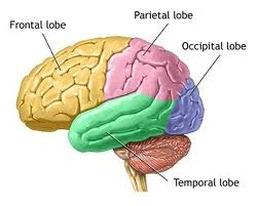

# Visualization

In [42]:
df.columns

Index(['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'T3', 'C3', 'Cz', 'C4',
       'T4', 'T5', 'P3', 'Pz', 'P4', 'status'],
      dtype='object')

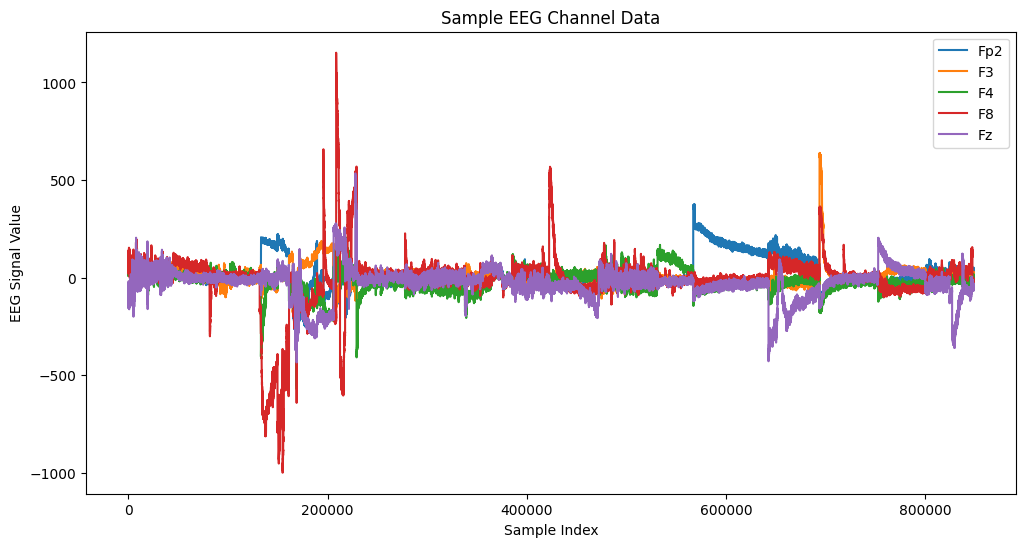

In [ ]:
channels_to_plot = ['Fp2', 'F3', 'F4', 'F8', 'Fz' ]
df[channels_to_plot].plot(figsize=(12,6), title='Sample EEG Channel Data')
plt.xlabel('Sample Index')
plt.ylabel('EEG Signal Value')
plt.show()



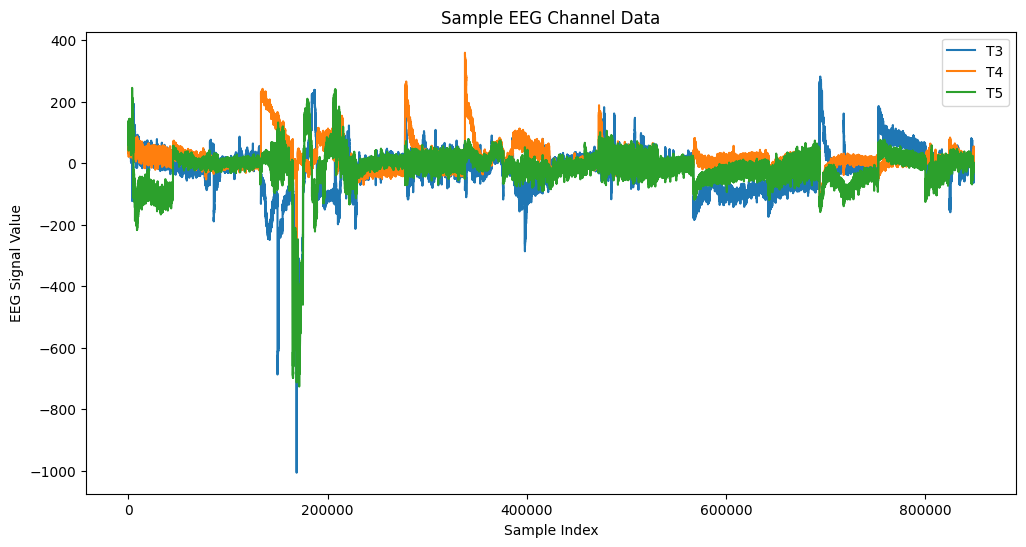

In [ ]:
channels_to_plot = ['T3','T4', 'T5' ]
df[channels_to_plot].plot(figsize=(12,6), title='Sample EEG Channel Data')
plt.xlabel('Sample Index')
plt.ylabel('EEG Signal Value')
plt.show()

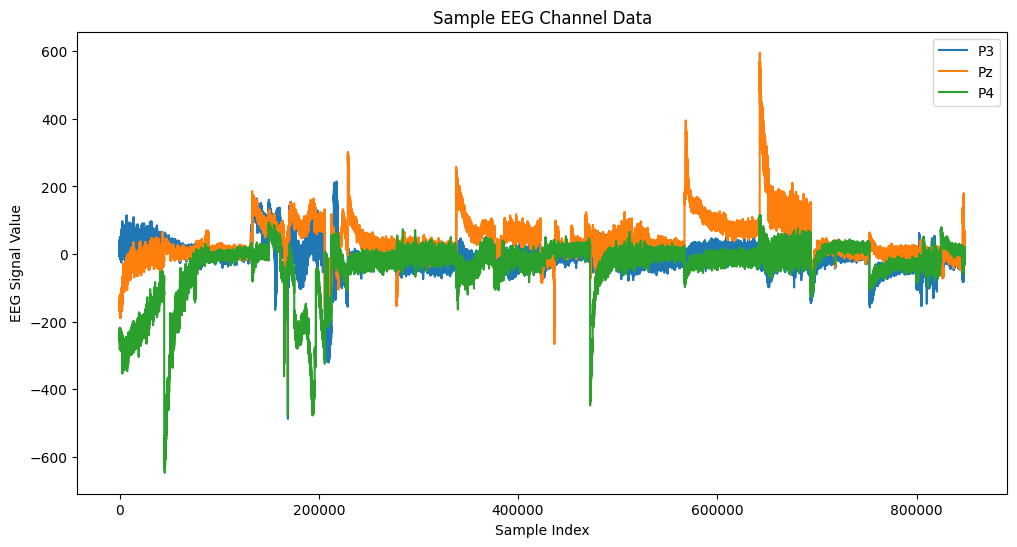

In [ ]:
channels_to_plot = ['P3', 'Pz', 'P4' ]  # You can add more
df[channels_to_plot].plot(figsize=(12,6), title='Sample EEG Channel Data')
plt.xlabel('Sample Index')
plt.ylabel('EEG Signal Value')
plt.show()

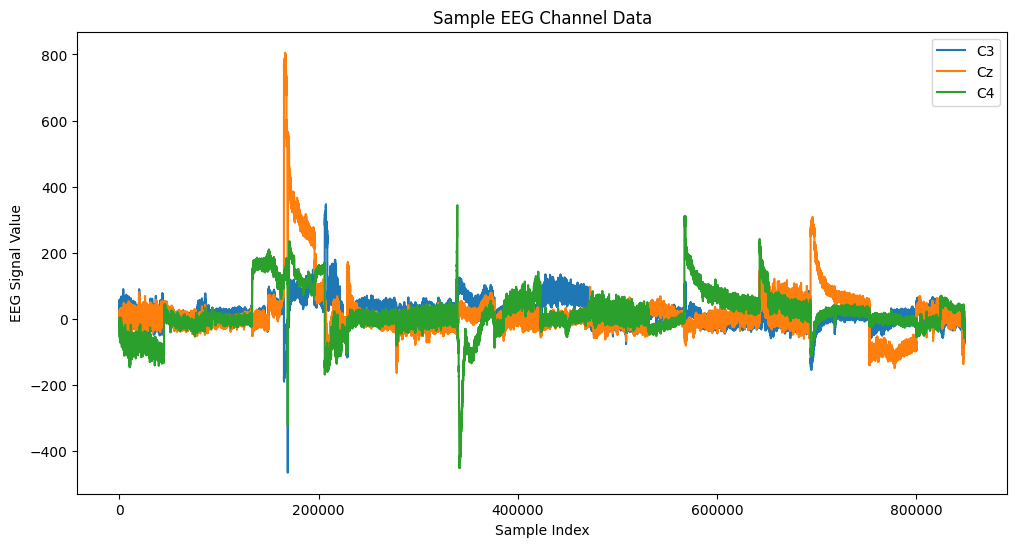

In [ ]:
channels_to_plot = ['C3', 'Cz', 'C4'] 
df[channels_to_plot].plot(figsize=(12,6), title='Sample EEG Channel Data')
plt.xlabel('Sample Index')
plt.ylabel('EEG Signal Value')
plt.show()

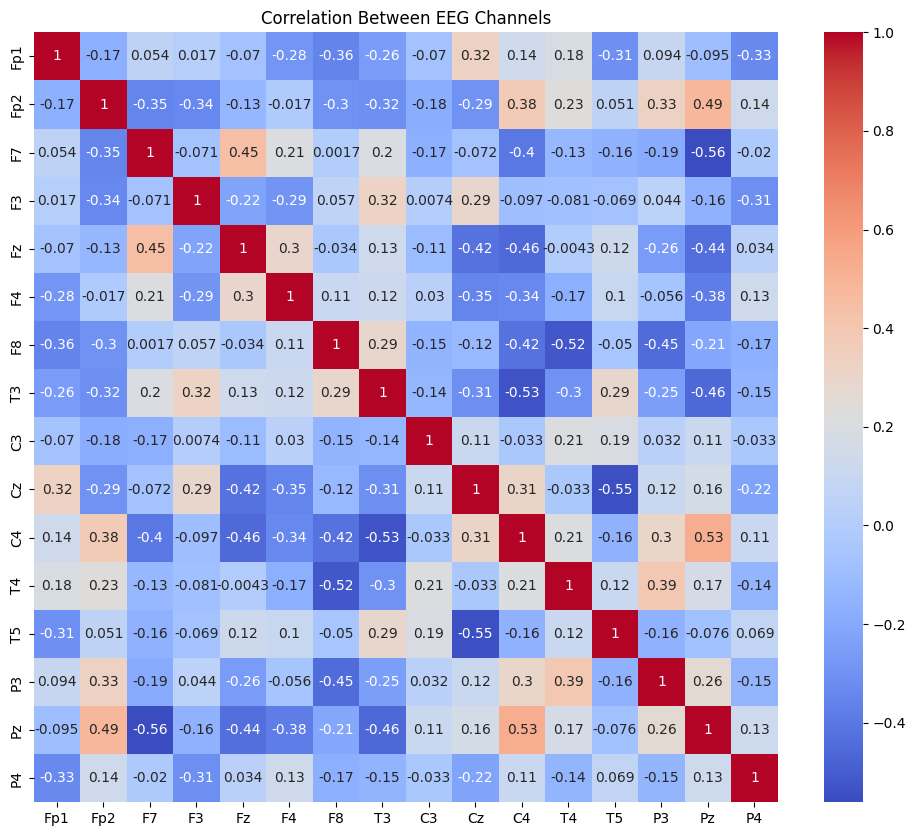

In [ ]:
# Correlation heatmap to see relationships between channels
plt.figure(figsize=(12,10))
sns.heatmap(df.drop('status', axis=1).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between EEG Channels")
plt.show()

In [ ]:
channels_to_plot = ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'T3', 'C3', 'Cz', 'C4', 'T4', 'T5', 'P3', 'Pz', 'P4', 'status']

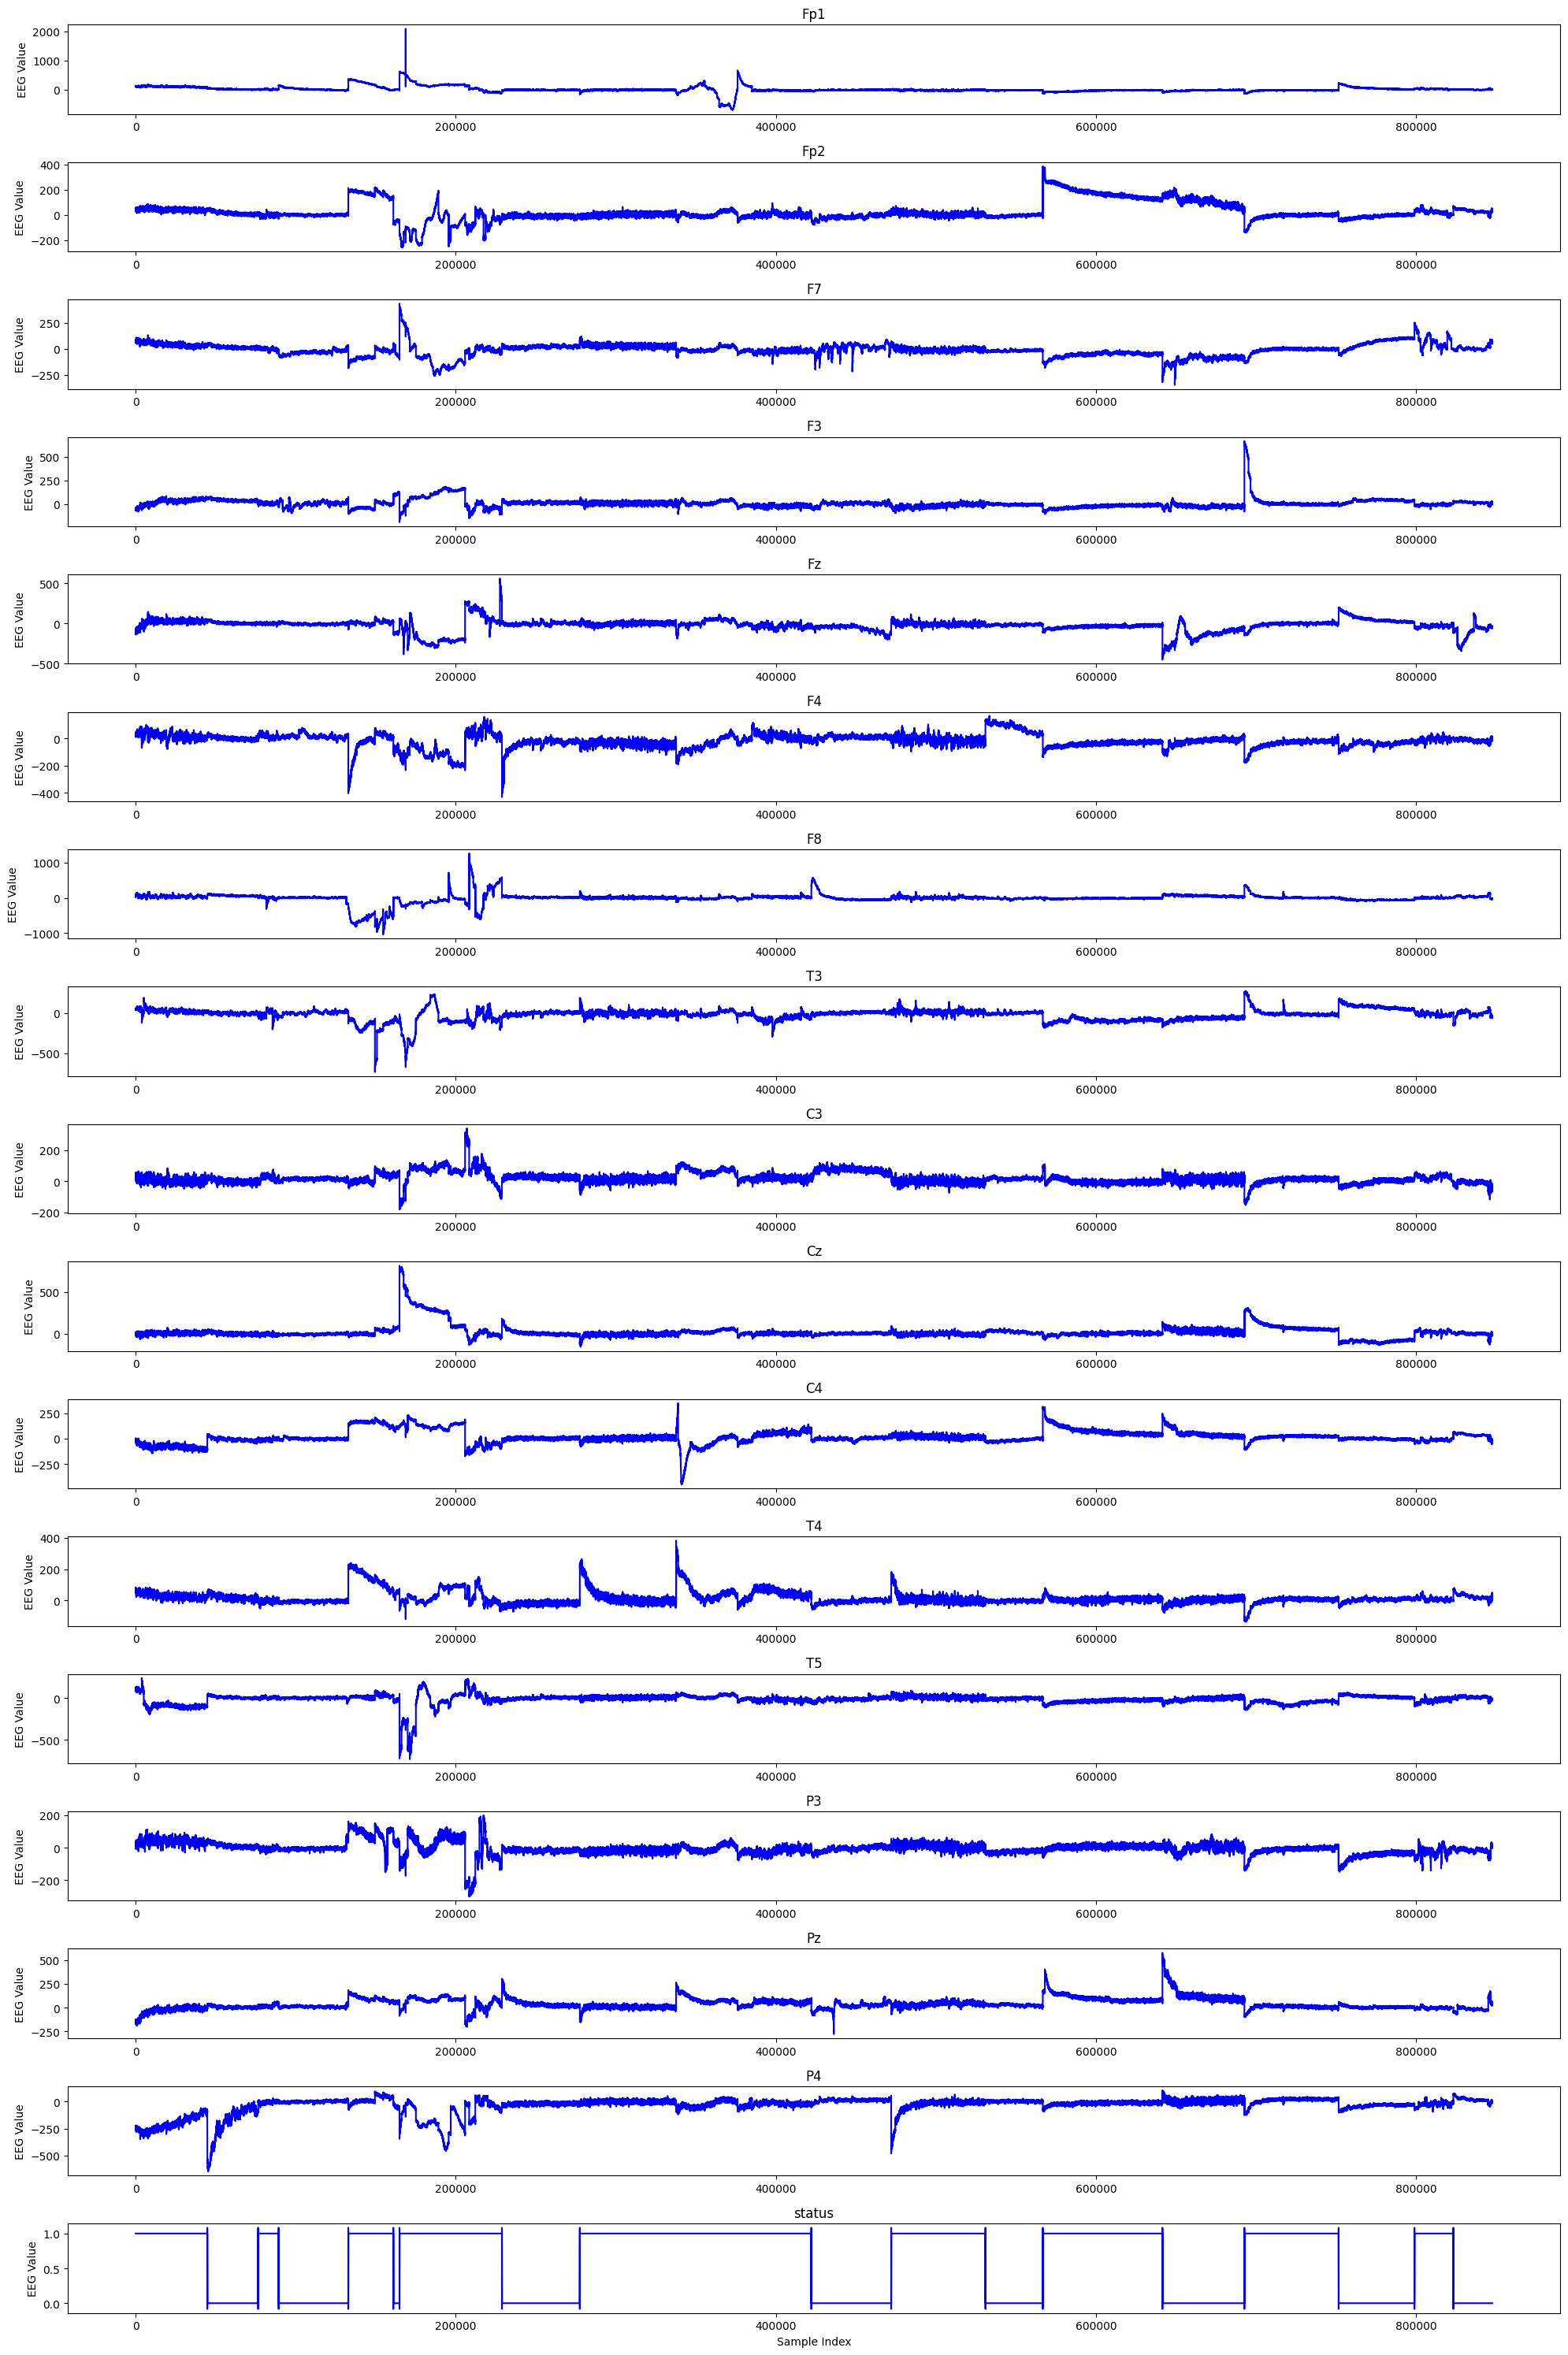

In [50]:
plt.figure(figsize=(20,30))
for i, ch in enumerate(channels_to_plot):
    plt.subplot(len(channels_to_plot), 1, i+1)
    smoothed = savgol_filter(df[ch], window_length=15, polyorder=5)
    plt.plot(smoothed, color='blue')
    plt.title(ch)
    plt.ylabel('EEG Value')
plt.xlabel('Sample Index')
plt.tight_layout()
plt.show()


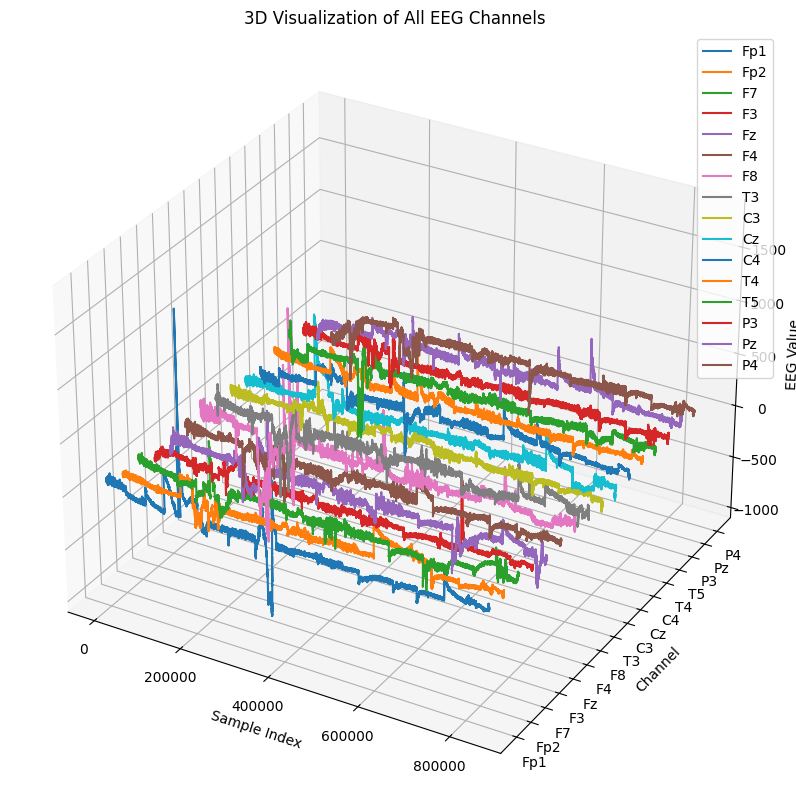

In [ ]:
# Smooth all signals using Savitzky-Golay filter
smoothed_df = df.copy()
for col in df.columns[:-1]:  # Exclude 'status'
    smoothed_df[col] = savgol_filter(df[col], window_length=11, polyorder=3)

# 3D plot
fig = plt.figure(figsize=(14,10))
ax = fig.add_subplot(111, projection='3d')

channels = smoothed_df.columns[:-1]  # all EEG channels
num_channels = len(channels)
x = np.arange(len(smoothed_df))

# Plot each channel as a separate line in 3D
for i, ch in enumerate(channels):
    y = np.full_like(x, i)  # channel index on y-axis
    z = smoothed_df[ch].values
    ax.plot(x, y, z, label=ch)

ax.set_xlabel('Sample Index')
ax.set_ylabel('Channel')
ax.set_zlabel('EEG Value')
ax.set_yticks(range(num_channels))
ax.set_yticklabels(channels)
ax.set_title('3D Visualization of All EEG Channels')
plt.legend()
plt.show()


In [ ]:
# # Downsample factor
# factor = 10  # keep every 10th sample

# # Smooth all signals
# smoothed_df = df.copy()
# for col in df.columns[:-1]:
#     smoothed_df[col] = savgol_filter(df[col], window_length=11, polyorder=3)

# # Downsample
# smoothed_df = smoothed_df.iloc[::factor, :]

# # 3D interactive plot
# fig = go.Figure()
# channels = smoothed_df.columns[:-1]
# x = list(range(len(smoothed_df)))

# for i, ch in enumerate(channels):
#     y = [i] * len(smoothed_df)
#     z = smoothed_df[ch].values
#     fig.add_trace(go.Scatter3d(x=x, y=y, z=z, mode='lines', name=ch))

# fig.update_layout(
#     scene=dict(
#         xaxis_title='Sample Index',
#         yaxis_title='Channel',
#         yaxis=dict(tickvals=list(range(len(channels))), ticktext=channels),
#         zaxis_title='EEG Value'
#     ),
#     title='Interactive 3D EEG Signals (Downsampled)',
#     width=900,
#     height=700
# )

# fig.show()


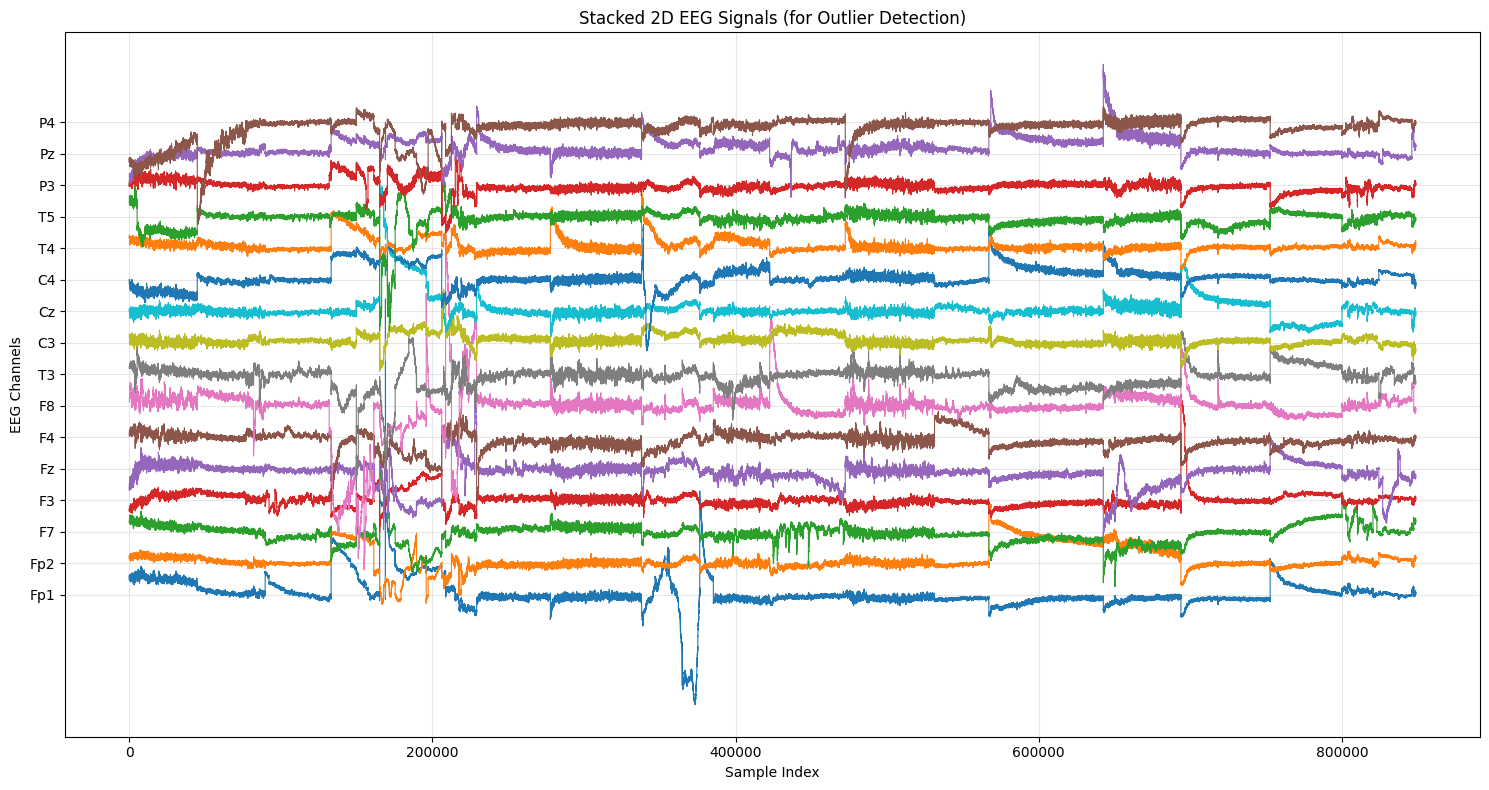

In [ ]:
# Smooth all signals
smoothed_df = df.copy()
for col in df.columns[:-1]:  # exclude 'status'
    smoothed_df[col] = savgol_filter(df[col], window_length=11, polyorder=3)

channels = smoothed_df.columns[:-1]
offset = 200  # distance between stacked channels, adjust as needed

plt.figure(figsize=(15,8))
for i, ch in enumerate(channels):
    plt.plot(smoothed_df[ch] + i*offset, label=ch, linewidth=0.8)

plt.yticks([i*offset for i in range(len(channels))], channels)
plt.xlabel('Sample Index')
plt.ylabel('EEG Channels')
plt.title('Stacked 2D EEG Signals (for Outlier Detection)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


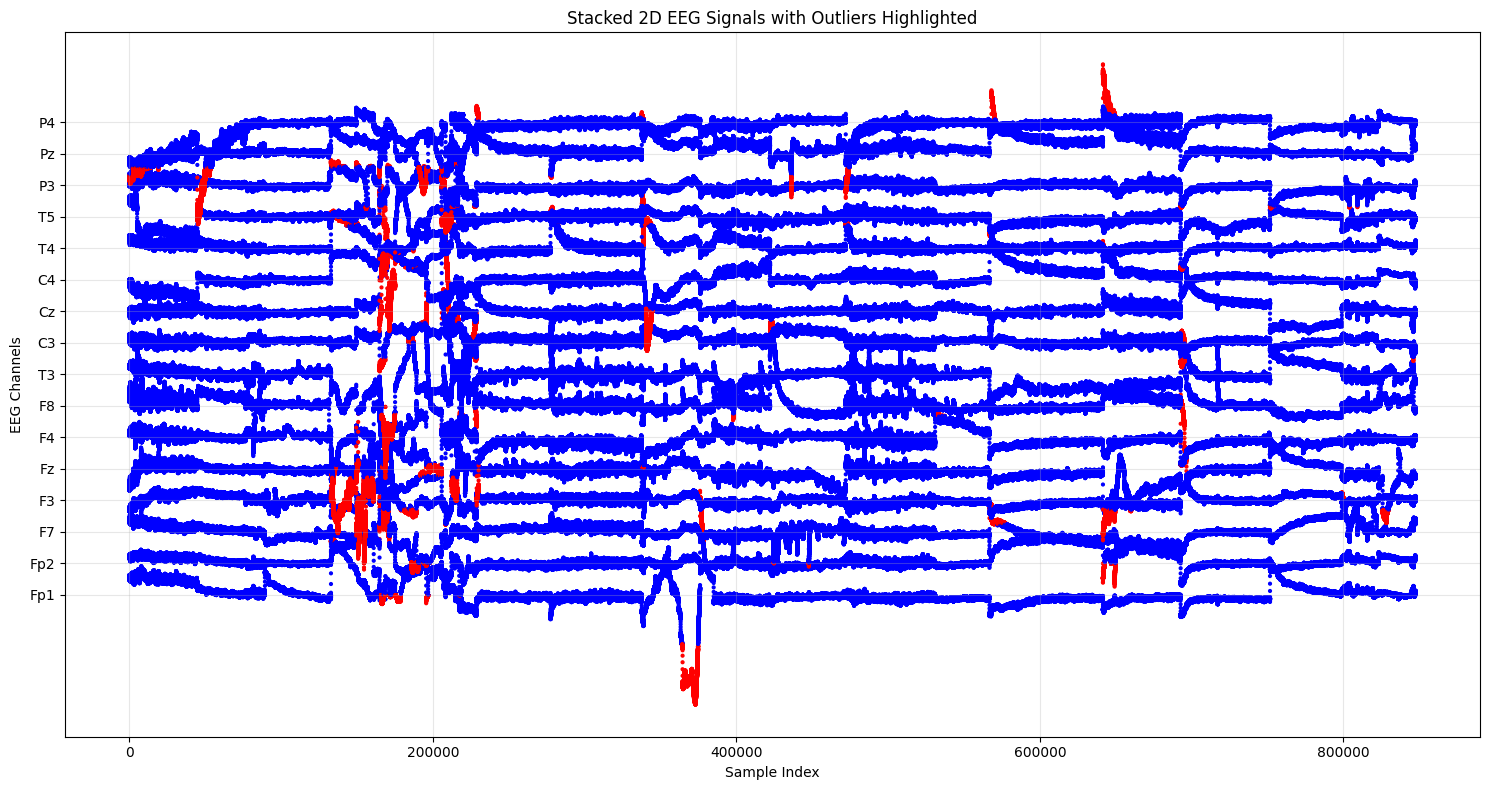

In [ ]:
# # Highlight outliers using z-score
# smoothed_vals = smoothed_df[channels].values
# z_scores = np.abs((smoothed_vals - smoothed_vals.mean(axis=0)) / smoothed_vals.std(axis=0))

# plt.figure(figsize=(15,8))
# for i, ch in enumerate(channels):
#     y = smoothed_df[ch] + i*offset
#     colors = np.where(z_scores[:, i] > 3, 'red', 'blue')  # red = outlier
#     plt.scatter(np.arange(len(y)), y, color=colors, s=4)

# plt.yticks([i*offset for i in range(len(channels))], channels)
# plt.xlabel('Sample Index')
# plt.ylabel('EEG Channels')
# plt.title('Stacked 2D EEG Signals with Outliers Highlighted')
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()


In [ ]:
# Step 1: Smooth all signals
smoothed_df = df.copy()
for col in df.columns[:-1]:  # exclude 'status'
    smoothed_df[col] = savgol_filter(df[col], window_length=11, polyorder=3)

# Step 2: Compute z-scores for all channels
values = smoothed_df[smoothed_df.columns[:-1]].values
z_scores = np.abs((values - values.mean(axis=0)) / values.std(axis=0))

# Step 3: Identify outliers (z-score > 3)
outlier_mask = z_scores > 3  # boolean array, True = outlier

# Step 4: Create a DataFrame of all outliers
# We'll keep only the original columns and add which channel(s) are outliers
outlier_rows = []
for row_idx in range(outlier_mask.shape[0]):
    channels_out = np.array(smoothed_df.columns[:-1])[outlier_mask[row_idx]]
    if len(channels_out) > 0:
        row_data = smoothed_df.iloc[row_idx].copy()
        row_data['outlier_channels'] = ','.join(channels_out)
        outlier_rows.append(row_data)

# Combine into a DataFrame
outliers_df = pd.DataFrame(outlier_rows)
print(f"Total outlier rows: {len(outliers_df)}")
display(outliers_df.head())


Total outlier rows: 148025


,Fp1,Fp2,F7,F3,Fz,F4,F8,T3,C3,Cz,C4,T4,T5,P3,Pz,P4,status,outlier_channels
21,124.273995,42.925277,75.774461,-61.435329,-119.471460,15.815953,28.990778,45.123878,38.629006,1.470731,-4.206425,71.683785,118.384717,3.069100,-139.810388,-241.218080,1.0,Pz
22,123.287063,45.566317,76.019930,-60.811072,-122.479138,16.003846,28.917366,44.724825,38.069580,-0.444639,-3.792890,73.291026,118.209207,3.201049,-140.254196,-239.508275,1.0,Pz
23,121.421620,46.943765,75.332576,-61.086772,-124.378380,16.102273,29.339103,44.120221,38.978497,1.017657,-3.583508,74.644930,115.790851,3.807401,-140.165093,-238.285140,1.0,Pz
24,119.381454,47.013622,73.419216,-61.849781,-125.911553,16.279123,30.194041,43.758843,40.045323,2.192410,-3.447684,74.942060,117.061874,4.777957,-139.389875,-238.467031,1.0,Pz
31,118.362500,40.209353,64.210286,-69.725845,-112.651486,19.238724,26.506323,43.016579,46.828700,9.473922,0.054341,75.350612,114.379983,2.888374,-139.681556,-238.460810,1.0,Pz


#### since outlier count is too high and removing outliers may cause biased dataset to i'm taking samples

In [65]:
window_size = 20  # number of samples per window
channels = df.columns[:-1]

outlier_rows = []

for ch in channels:
    for start in range(0, len(df), window_size):
        end = start + window_size
        window = df[ch].iloc[start:end]
        window_mean = window.mean()
        window_std = window.std()
        z_scores = np.abs((window - window_mean) / window_std)
        if (z_scores > 4).any():  # flag only if window has extreme values
            outlier_rows.extend(df.iloc[start:end].index.tolist())

# Remove duplicates
outlier_rows = list(set(outlier_rows))

print(f"Number of rows with windowed outliers: {len(outlier_rows)}")
outliers_df = df.iloc[outlier_rows].copy()


Number of rows with windowed outliers: 260


In [66]:
outliers_df.shape

(260, 17)

In [67]:
# Remove outliers from the original DataFrame
clean_df = df.drop(outliers_df.index).reset_index(drop=True)

print(f"Original dataset shape: {df.shape}")
print(f"Cleaned dataset shape (after removing outliers): {clean_df.shape}")
# Save cleaned data
clean_df.to_csv('cleaned.csv', index=False)

Original dataset shape: (847604, 17)
Cleaned dataset shape (after removing outliers): (847344, 17)


Class distribution:
status
1    510960
0    336384
Name: count, dtype: int64


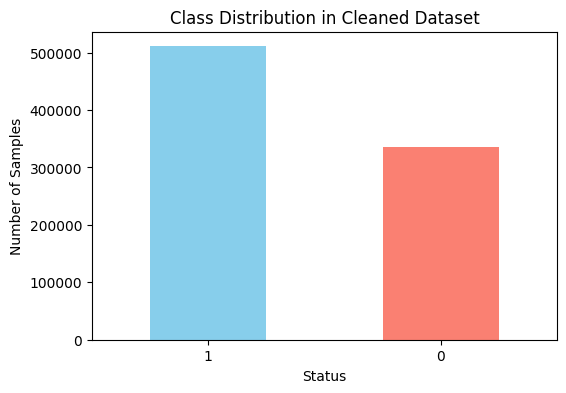

Class '1' ratio: 60.30%
Class '0' ratio: 39.70%


In [68]:
# Check the distribution of the target variable
target_counts = clean_df['status'].value_counts()
print("Class distribution:")
print(target_counts)

# Visualize the distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
target_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Class Distribution in Cleaned Dataset')
plt.xlabel('Status')
plt.ylabel('Number of Samples')
plt.xticks(rotation=0)
plt.show()

# Optional: compute class ratio
total = target_counts.sum()
for cls, count in target_counts.items():
    print(f"Class '{cls}' ratio: {count/total:.2%}")


There is slight imbalance in dataset, but this won't affect model too much.

Anyway we are going to use:
#### -Class weights (we can assign higher weight to minority class during training.)-